In [1]:
using LinearAlgebra
using BoundaryValueDiffEq
using Plots
using DifferentialEquations
using BSplineKit
using DelimitedFiles
using Loess

In [2]:
function sol_baseflowODE(tspan,Num)

    function oneDiskODE!(du, u , p, t)
        
        U = u[1]
        dU = u[2]
        V = u[3]
        dV = u[4]
        W = u[5]
        du[1] = dU
        ddU = U^2 + W*dU - (V+1.0e0)^2
        du[2] = ddU
        ddV = 2.0e0*U*(V + 1.0e0) + W*dV
        du[3] = dV
        du[4] = ddV                          
        du[5] = -2.0e0*U

    end
    function oneDiskbc!(residual, u , p, t)

        residual[1] = u[begin][1] 
        residual[2] = u[begin][3] 
        residual[3] = u[begin][5] 
        residual[4] = u[end][1] 

        residual[5] = u[end][3] + 1.0e0
    end
        prob = BVProblem(oneDiskODE!, oneDiskbc!, [0.0, 0.5103341351120374, 0.0, -0.6151547026271073, 0.0] ,tspan, dtmax=0.01)
        sol = solve(prob, Shooting(Vern7()), dt=0.001)
        t=range(0.0, 20, Num)
        u=sol(t)
    
    return u , t

end

sol_baseflowODE (generic function with 1 method)

In [3]:
function velocity(u)

    U = u[1 , :]
    dU = u[2 , :]
    V = u[3 , :]
    dV = u[4 , :]
    W = u[5 , :]
    F_U = itp = interpolate(t, U , BSplineOrder(4))
    F_dU = itp = interpolate(t, dU , BSplineOrder(4))
    F_dV = itp = interpolate(t, dV , BSplineOrder(4))
    F_W= itp = interpolate(t, W , BSplineOrder(4))
    
    return U,dU,V,dV,W,F_U,F_dU,F_dV,F_W

end

velocity (generic function with 1 method)

In [4]:
function T_start(F_dU,F_dV,F_W,sigma,Mx,gamma,Tw,tspan,Num)
    Mx = Mx
    gamma = gamma
    Tw = Tw
    sigma = sigma
    function ODE_T!(du,u,p,t)
        T = u[1]
        dT = u[2]
        du[1] = dT
        du[2] = (F_W(t) * u[2] )*sigma
    end
    function bc2!(residual, u, p, t)
        residual[1] = u[begin][1] - Tw
        residual[2] = u[end][1] - 1
    end
        prob = BVProblem(ODE_T! , bc2! , [0,0] , tspan)
        sol = solve(prob , Shooting(Vern7()) , dt = 0.001)
        t=range(0.0, 20, Num)
        T=sol(t)
        dT = T[2,:]
        T = T[1,:]
    return T , dT

end

T_start (generic function with 1 method)

In [5]:
function Cheb(u,v,w,T,t,N)
    θ = range(0,length=N+1,stop=pi)
    x = reshape(-cos.(θ), N+1, 1)
    c = [2; ones(N-1, 1) ; 2] .* (-1) .^ (0:N)
    X = repeat(x, 1, N+1);
    dX = X - X';
    D = (c * (1 ./ c)') ./ (dX .+ I(N+1));
    D = D - diagm(vec(sum(D, dims=2))); 
    for i=1:N+1
        x[i] = 7.5 * x[i] .+ 7.5
    end
    D = (2/15) * D
    # for i=1:N+1
    #     D[i,:]=D[i,:].*((2*x[i]^3-x[i]^2+3*x[i]-4)^2/(20*(6*x[i]^2-2*x[i]+3)))
    # end
    # for i=1:N+1
    #     x[i]=(4*x[i]^3-2*x[i]^2+6*x[i]+12)/(-2*x[i]^3+x[i]^2-3*x[i]+4)
    #     if x[i]>15
    #         x[i]=15
    #     end
    # end
    itpw = itp = interpolate(t, w , BSplineOrder(4))
    itpu = itp = interpolate(t, u , BSplineOrder(4))
    itpv = itp = interpolate(t, v , BSplineOrder(4))
    itpT = itp = interpolate(t, T , BSplineOrder(4))
    u = zeros(N+1,1)
    v = zeros(N+1,1)
    w = zeros(N+1,1)
    T = zeros(N+1,1)
    for i=1:N+1
        u[i,1] = itpu(x[i])
        v[i,1] = itpv(x[i])
        w[i,1] = itpw(x[i])
        T[i,1] = itpT(x[i])
    end
    return D,x,u,v,w,T
end

Cheb (generic function with 1 method)

In [6]:
function var!(x,x1)
    a = length(x)
    b = x1 .- x
    d = 0
    for i = 1 : a
        c = b[i,1]^2
        d = c + d 
    end
    e = sqrt(d) / a
    return e
end

var! (generic function with 1 method)

In [387]:
d2u[2:end-1,1] .- W[2:end-1,1] .* du[2:end-1,1] .- U[2:end-1,1] .* U[2:end-1,1] .+ (V[2:end-1,1] .+ 1) .* (V[2:end-1,1] .+ 1)

148-element Vector{Float64}:
 -2.018006317605625e-9
  2.610059945951093e-10
  1.6825429938194247e-12
  9.992007221626409e-13
 -1.8487211761453182e-11
  2.02992067599439e-11
 -1.1933232180183495e-11
  4.174993684102901e-12
 -4.147238108487272e-12
  4.178657420084164e-12
  ⋮
  3.315932928814251e-15
 -1.7103674028996286e-15
  4.095331518304073e-15
 -2.3214887055127336e-15
  4.7374419859523e-15
 -7.17484915267648e-15
  1.1648277789558442e-14
 -2.0721755600035504e-14
  8.862593773386136e-14

In [19]:
-1 .* W[2:end-1,1] .* dT[2:end-1,1]*sigma .+ d2T[2:end-1,1]

148-element Vector{Float64}:
  4.565931518435077e-8
 -1.1475857862415701e-8
  5.145105066612995e-9
 -2.9542952250131635e-9
  1.9242956979514123e-9
 -1.3437584904930737e-9
  9.775767266539427e-10
 -8.098822781030593e-10
 -1.9562366341619244e-9
 -6.098679766492615e-10
  ⋮
 -2.1139442382721915e-9
 -2.154219960455537e-9
 -2.7886745031269775e-9
 -2.506993381387422e-9
 -3.404069429527106e-9
 -2.439496651217868e-9
 -4.4408391140723935e-9
 -5.603008772957696e-10
 -1.4300873714672303e-8

In [33]:
T1 = T[2:end-1,1] .+ (1 ./ U[2:end-1,1]) .* (delx/x_i).*(  -1 .* W[2:end-1,1] .* dT[2:end-1,1] .+ (1/sigma) .* d2T[2:end-1,1])
insert!(T1,1,Tw);insert!(T1,N+1,1);
for i = 2 : 1 : N+1 
    if abs(T1[i,1] - T1[i-1,1]) < 0.001 && 1<T1[i,1]<1.1
        T1[i:end,1] .= T1[i,1]
    end
end
dT1 = D * T1
d2T1 = D^2 * T1

plot(x,d2T)
plot!(x,d2T1)

true

In [17]:
tspan = (0,20)
Num = 20001
sigma = 0.7
Ma = 6
x_i = 0.0001
delx=0.0001
Mx = Ma * x_i
Tw = 0.5
gamma = 1.4
N = 149
u,t = sol_baseflowODE(tspan,Num)
U,dU,V,dV,W,F_U,F_dU,F_dV,F_W = velocity(u)
T,dT = T_start(F_dU,F_dV,F_W,sigma,Mx,gamma,Tw,tspan,Num)
D,x,U,V,W,T = Cheb(U,V,W,T,t,N)
d2u = D^2 * U
du = D * U
d2v = D^2 *V
dv = D * V
dT = D * T 
d2T = D^2 * T
# u1 = U[2:end-1,1] .+ (1 ./ U[2:end-1,1]) .*(delx/x_i).* (d2u[2:end-1,1] .- W[2:end-1,1] .* du[2:end-1,1] .- U[2:end-1,1] .* U[2:end-1,1] .+ (V[2:end-1,1] .+ 1) .* (V[2:end-1,1] .+ 1))
# v1 = V[2:end-1,1] .+ (1 ./ U[2:end-1,1]) .*(delx/x_i).* (d2v[2:end-1,1] .- W[2:end-1,1] .* dv[2:end-1,1] .- 2*U[2:end-1,1] .* V[2:end-1,1] .- 2*U[2:end-1,1])
# T1 = T[2:end-1,1] .+ (1 ./ U[2:end-1,1]) .* (delx/x_i).*(((Mx^2 *(gamma - 1)) .*(du[2:end-1,1] .* du[2:end-1,1] + dv[2:end-1,1] .* dv[2:end-1,1] )) .- W[2:end-1,1] .* dT[2:end-1,1] .+ (1/sigma) .* d2T[2:end-1,1])
# insert!(u1,1,0);insert!(u1,N+1,u1[N-1,1]);
# insert!(v1,1,0);insert!(v1,N+1,-1);
# insert!(T1,1,Tw);insert!(T1,N+1,1);
# for i = 2 : 1 : N+1 
#     if abs(T1[i,1] - T1[i-1,1]) < 0.001 && 1<T1[i,1]<1.1
#         T1[i:end,1] .= T1[i,1]
#     end
# end
# dT1 = D * T1
# d2T1 = D^2 * T1
# T_temp = T1
# dT_temp = dT1
# d2T_temp = d2T1
# for i = 1
#     T = T_temp[2:end-1,1] .+ (1 ./ U[2:end-1,1]) .*(0.001/x_i).* (((Mx^2 *(gamma - 1)) .*(du[2:end-1,1] .* du[2:end-1,1] + dv[2:end-1,1] .* dv[2:end-1,1] )) .- W[2:end-1,1] .* dT_temp[2:end-1,1] .+ (1/sigma) .* d2T_temp[2:end-1,1])
#     insert!(T,1,Tw);insert!(T,N,1);
#     dT = D * T
#     d2T = D^2 * T
#     T_temp = T
#     dT_temp = dT
#     d2T_temp = d2T
# end
# plot(x,dT)
# plot!(x,dT1)

150×1 Matrix{Float64}:
  6.001033937195355e-7
 -1.1452473693647811e-7
 -2.5654928429949087e-6
 -1.2849586245643071e-5
 -4.0300772374668465e-5
 -9.735653164485061e-5
 -0.0001993151139066515
 -0.0003637013390059115
 -0.0006096957538933029
 -0.0009573941372915459
  ⋮
 -3.0564863983787794e-5
 -3.009792516117295e-5
 -2.9697703737407155e-5
 -2.936412840592177e-5
 -2.9092025414397934e-5
 -2.8884828627716556e-5
 -2.873229916052643e-5
 -2.8657263285158307e-5
 -2.8760522859419673e-5

In [315]:
@show d2T1

d2T1 = [-11.511606724711498, -4.244673287920703, 0.631171698604147, -0.08700885259108831, 0.033848263887131, -0.01587427319107114, 0.006434809408872838, -0.009352157161134397, -0.0025555570807185707, -0.012226673432844691, -0.011046943897115014, -0.019310826747931425, -0.020920548298496894, -0.02844890818048449, -0.030898717180449578, -0.037341450782989935, -0.038998613961687745, -0.0433508226468201, -0.0433977131717928, -0.04533119861758002, -0.04299432740368641, -0.043542588617331665, -0.03893567882317287, -0.03877446731022051, -0.03282613330976511, -0.03104642383629463, -0.027050071938376496, -0.024652009757712697, -0.020188213194870033, -0.018629033845109784, -0.014878159540439431, -0.014197166497991692, -0.010527253754322905, -0.009629983574184733, -0.007536029197385666, -0.007361027194247473, -0.005195287607880248, -0.005146884377127403, -0.002992178605236902, -0.003772084142563064, -0.002002788413528543, -0.004028162291906834, -0.001102592471673533, -0.0018075075026303018, 0.000

80-element Vector{Float64}:
  -11.511606724711498
   -4.244673287920703
    0.631171698604147
   -0.08700885259108831
    0.033848263887131
   -0.01587427319107114
    0.006434809408872838
   -0.009352157161134397
   -0.0025555570807185707
   -0.012226673432844691
    ⋮
   -0.45536853806969724
    0.7745475538905495
   -1.533453680975967
    3.2732950487687305
   -8.165947396381853
   25.599747504422567
 -117.60084938185395
  608.0494716485009
 1531.2277089865584

In [310]:
T_temp[2:end-1,1] .+ (1 ./ U[2:end-1,1]) .* (((Mx^2 *(gamma - 1)) .*(du[2:end-1,1] .* du[2:end-1,1] + dv[2:end-1,1] .* dv[2:end-1,1] )) .- W[2:end-1,1] .* dT_temp[2:end-1,1] .+ (1/sigma) .* d2T_temp[2:end-1,1])

78-element Vector{Float64}:
   -2015.4633698482153
      76.80019741612657
      -4.298442959755091
       1.6300828379409
       0.20061258194612203
       0.6762155892675306
       0.4765244722657149
       0.6025787286413025
       0.5492157212690866
       0.6141543687586728
       ⋮
  159543.59842206034
 -325920.2589238201
  577226.4196185338
      -1.209629468657386e6
       2.675804840762588e6
      -6.928822896109239e6
       2.230223469472419e7
      -1.0454222156334949e8
       5.468360861533656e8

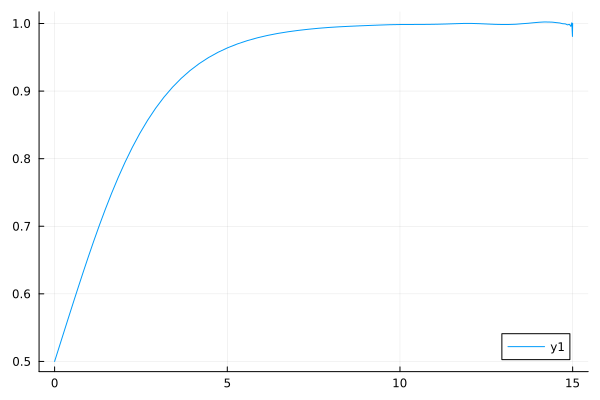

In [308]:
plot(x,T_temp)

In [ ]:
data=[x U u1 V v1 T T1]

In [219]:
writedlm("pdf_vs_ode.dat",data,'\t')